## CS-SHRED

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
import json
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import itertools
import time
import matplotlib.pyplot as plt


In [5]:
# Define os caminhos de salvamento e carregamento
save_path = r"./sst_cs-shred"
load_path = r"./sst_cs-shred"


# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")


test_recons (168, 180, 360)
test_ground_truth (168, 180, 360)
Training error plot saved to ./sst_cs-shred/plot_training_error.png


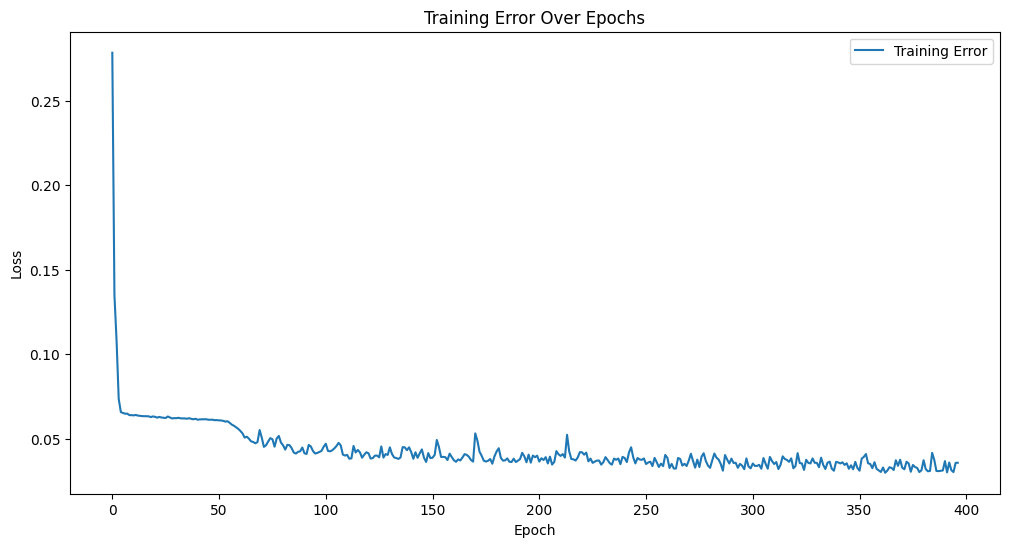

Validation error plot saved to ./sst_cs-shred/plot_validation_error.png


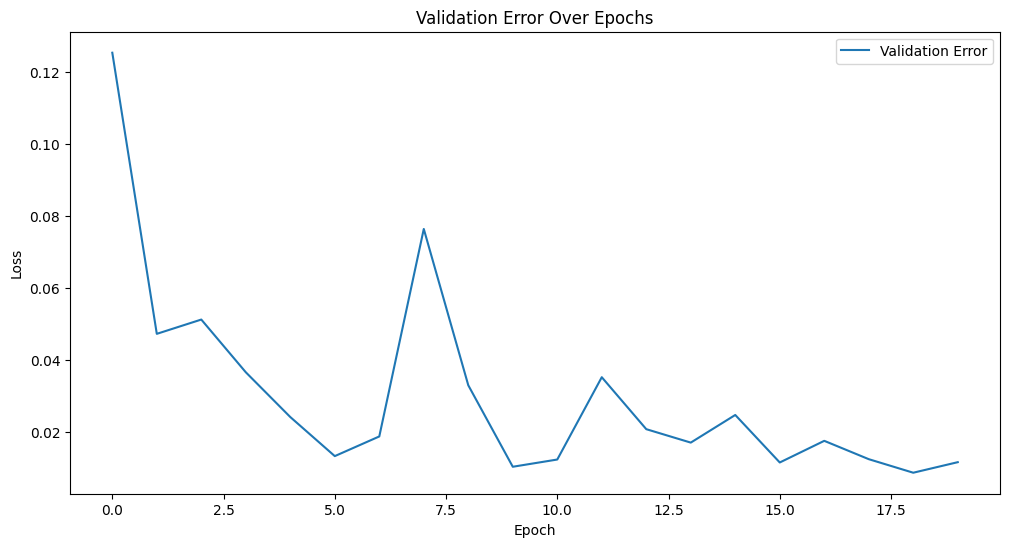

Reconstructed vs Original plot saved to ./sst_cs-shred/plot_reconstructed_vs_original.png


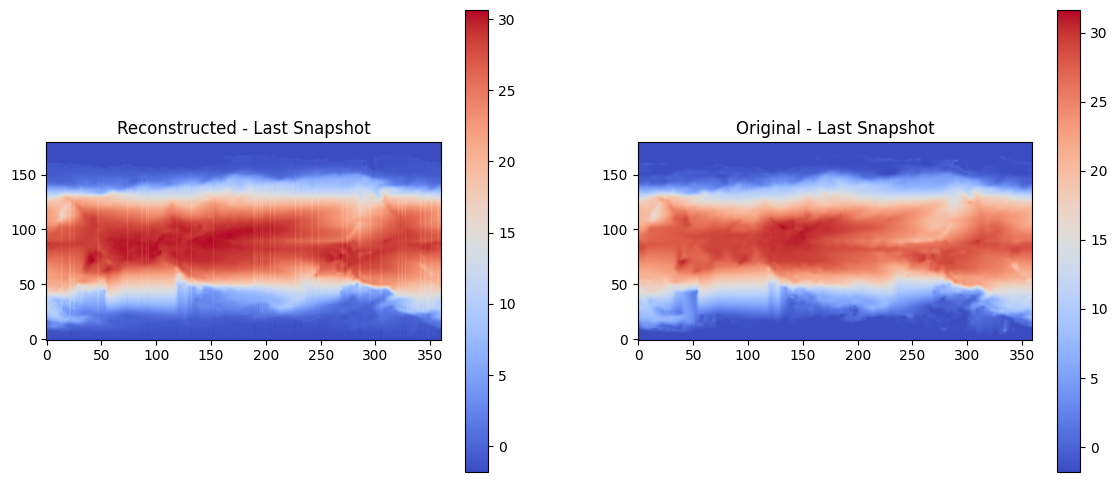

Reconstructed vs Subsampled plot saved to ./sst_cs-shred/plot_reconstructed_vs_subsampled.png


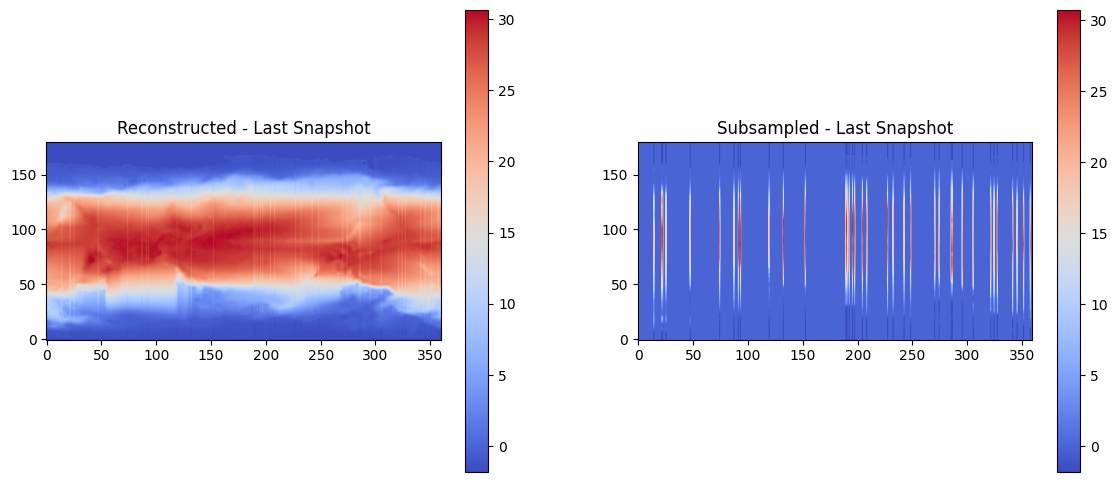

SSIM for the last snapshot: 0.8716748996986537
SSIM value saved to ./sst_cs-shred/plot_ssim.json


In [6]:
def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_plot=False, save_path=None, file_prefix="plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundos
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_training_error.png")
        plt.savefig(save_file)
        print(f"Training error plot saved to {save_file}")
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_validation_error.png")
        plt.savefig(save_file)
        print(f"Validation error plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Original - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(test_ground_truth[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Original - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_original.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Original plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Subsampled - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(subsampled[:, :, -1], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Subsampled - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_subsampled.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Subsampled plot saved to {save_file}")
    plt.show()

    # Calculate SSIM
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM for the last snapshot: {ssim_value}")

    # Save SSIM value to JSON
    if save_plot:
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, 'w') as f:
            json.dump({'SSIM': float(ssim_value)}, f)
        print(f"SSIM value saved to {ssim_file}")

    plt.show()


plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_plot=True, save_path=save_path, file_prefix="plot"
)



Plot saved to ./sst_cs-shred/humidity_analysis_reconstructed_last_snapshot.pdf


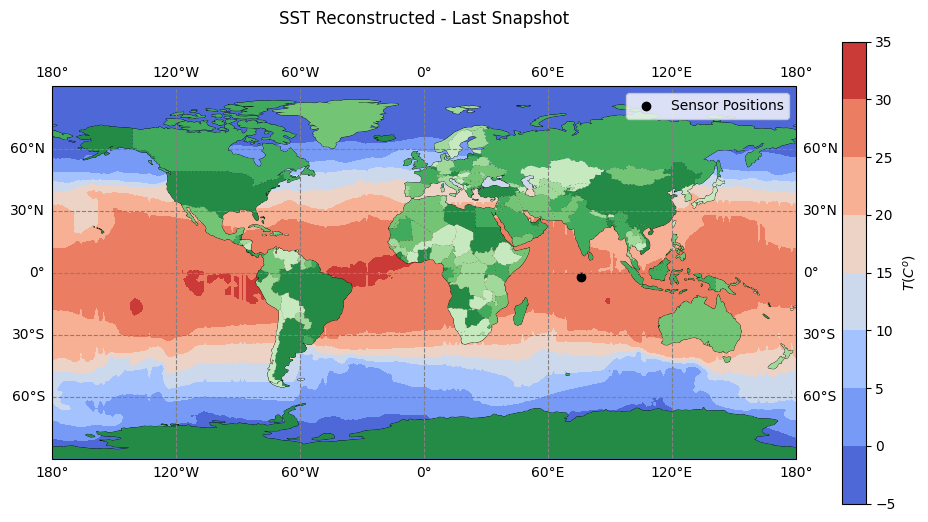

Plot saved to ./sst_cs-shred/humidity_analysis_original_last_snapshot.pdf


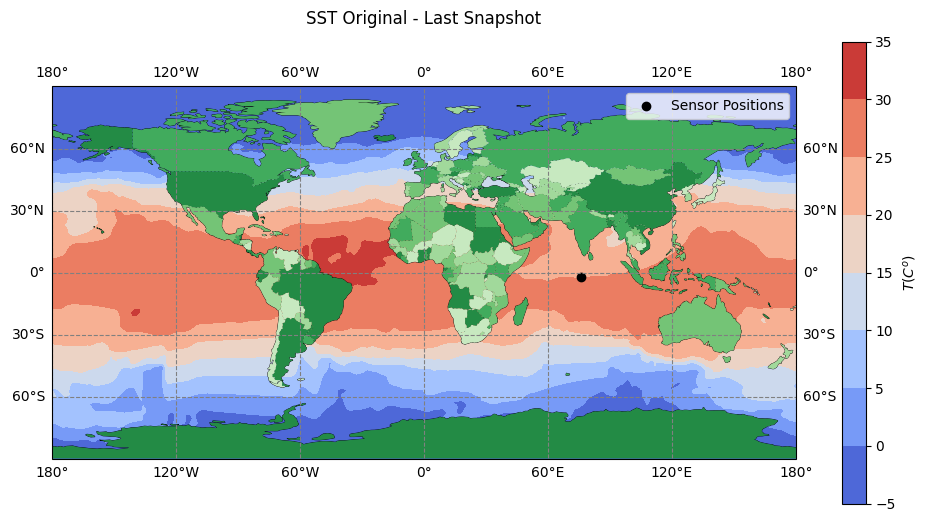

Plot saved to ./sst_cs-shred/humidity_analysis_subsampled_last_snapshot.pdf


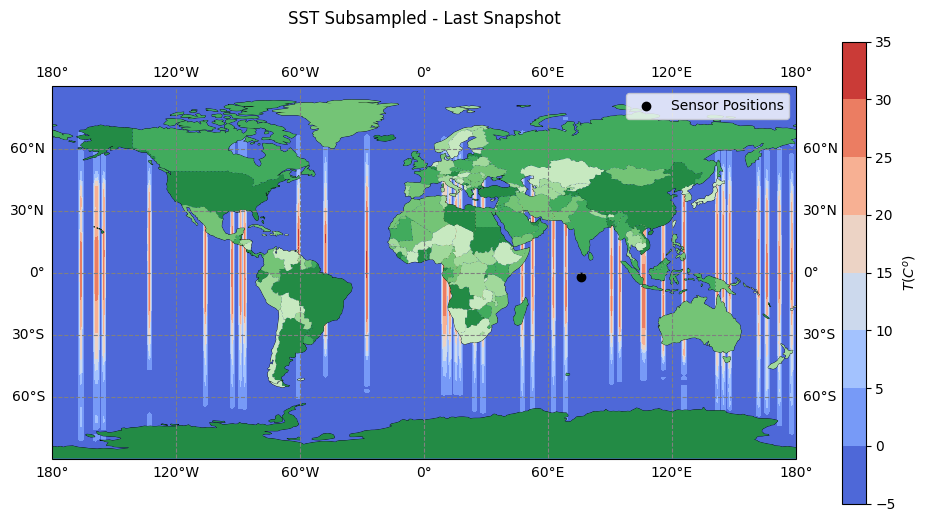

SSIM of SST - last snapshot: 0.8716748996986537
SSIM value saved to ./sst_cs-shred/humidity_analysis_ssim.json
Plot saved to ./sst_cs-shred/humidity_analysis_high_humidity_areas.pdf


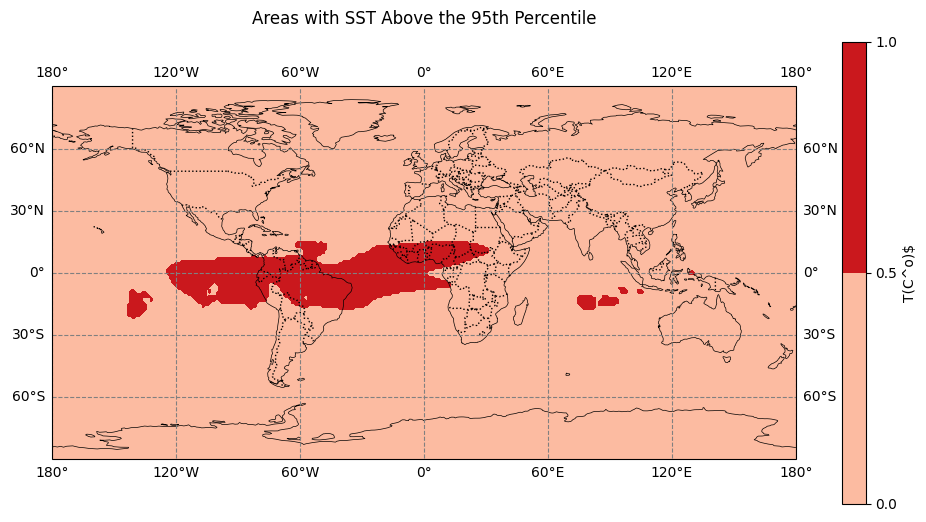

Plot saved to ./sst_cs-shred/humidity_analysis_SST.pdf


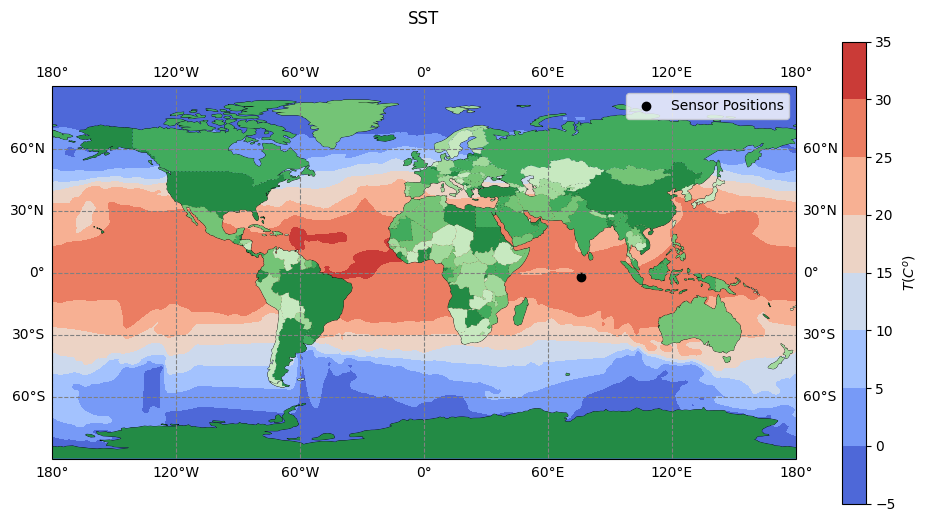

In [7]:

def plot_with_map(
    data, title, label, sensor_positions_x, sensor_positions_y, 
    save_path=None, file_name=None
):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, data.shape[1]),
        np.linspace(-90, 90, data.shape[0]),
        data,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Ajustar as coordenadas dos sensores para o sistema de referência geográfica
    sensor_lon = sensor_positions_x * 360 - 180  # Converter de [0,1] para [-180,180]
    sensor_lat = sensor_positions_y * 180 - 90  # Converter de [0,1] para [-90,90]

    ax.scatter(sensor_lon, sensor_lat, color="k", label="Sensor Positions")
    ax.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo

    # Carregar shapefile de países
    shapename = "admin_0_countries"
    countries_shp = shpreader.natural_earth(
        resolution="110m", category="cultural", name=shapename
    )

    # Definir cores "terrosas"
    earth_colors = (
        np.array(
            [
                (199, 233, 192),
                (161, 217, 155),
                (116, 196, 118),
                (65, 171, 93),
                (35, 139, 69),
            ]
        )
        / 255.0
    )
    earth_colors = itertools.cycle(earth_colors)

    # Adicionar geometria dos países ao mapa
    for country in shpreader.Reader(countries_shp).records():
        ax.add_geometries(
            country.geometry,
            ccrs.PlateCarree(),
            facecolor=next(earth_colors),
            label=country.attributes["NAME"],
        )

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label(label)
    plt.title(title, pad=30)

    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.pdf")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_high_humidity_areas(mean_SST, title, save_path=None, file_name=None):
    high_SST_areas = mean_SST > np.percentile(mean_SST, 95)  # Áreas com umidade específica máxima no maior percentil 5%
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, high_SST_areas.shape[1]),
        np.linspace(-90, 90, high_SST_areas.shape[0]),
        high_SST_areas,
        transform=ccrs.PlateCarree(),
        cmap="Reds",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label('T(C^o)$')
    plt.title(title, pad=30)
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    
    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.pdf")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    subsampled,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=None,
    file_prefix="cartografy_plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot 3: Reconstruído - Última Imagem com Continentes
    plot_with_map(
        test_recons[-1, :, :],
        "SST Reconstructed - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_reconstructed_last_snapshot"
    )

    # Plot 4: Original - Última Imagem com Continentes 
    plot_with_map(
        test_ground_truth[-1, :, :],
        "SST Original - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_original_last_snapshot"
    )

    # Plot 5: Subamostrado - Última Imagem com Continentes
    plot_with_map(
        subsampled[:, :, -1],
        "SST Subsampled - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_subsampled_last_snapshot"
    )

    # Calcular e imprimir o SSIM para a última imagem
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM of SST - last snapshot: {ssim_value}")

    if save_plot and save_path is not None:
        ssim_data = {"ssim_value": ssim_value}
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, "w") as f:
            json.dump(ssim_data, f)
        print(f"SSIM value saved to {ssim_file}")

    # Plotar áreas com alta umidade específica
    mean_SST = np.mean(matrix, axis=0)
    plot_high_humidity_areas(
        mean_SST, 
        'Areas with SST Above the 95th Percentile',
        save_path=save_path,
        file_name=f"{file_prefix}_high_humidity_areas"
    )

    SST = matrix[-1, :, :]
    plot_with_map(
        SST,
        "SST",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_SST"
    )

plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    snapshot,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=save_path,  
    file_prefix='humidity_analysis' 
)



## SHRED

In [ ]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/qmax"
# load_path = r"./results/csshred/qmax"

save_path = r"/home/romulo/Documentos/lpips-env/results/shred/qmax"
load_path = r"/home/romulo/Documentos/lpips-env/results/shred/qmax"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
# train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")


In [ ]:
def plot_results(
     validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_plot=False, save_path=None, file_prefix="plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot Training Error
    # plt.figure(figsize=(12, 6))
    # plt.plot(train_error, label="Training Error")
    # plt.xlabel("Epoch")
    # plt.ylabel("Loss")
    # plt.title("Training Error Over Epochs")
    # plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundos
    
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_training_error.png")
        plt.savefig(save_file)
        print(f"Training error plot saved to {save_file}")
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_validation_error.png")
        plt.savefig(save_file)
        print(f"Validation error plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Original - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(test_ground_truth[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Original - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_original.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Original plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Subsampled - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(subsampled[:, :, -1], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Subsampled - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_subsampled.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Subsampled plot saved to {save_file}")
    plt.show()

    # Calculate SSIM
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM for the last snapshot: {ssim_value}")

    # Save SSIM value to JSON
    if save_plot:
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, 'w') as f:
            json.dump({'SSIM': float(ssim_value)}, f)
        print(f"SSIM value saved to {ssim_file}")

    plt.show()



plot_results(
     validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_plot=True, save_path=save_path, file_prefix="plot"
)


In [ ]:

def plot_with_map(
    data, title, label, sensor_positions_x, sensor_positions_y, 
    save_path=None, file_name=None
):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, data.shape[1]),
        np.linspace(-90, 90, data.shape[0]),
        data,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Ajustar as coordenadas dos sensores para o sistema de referência geográfica
    sensor_lon = sensor_positions_x * 360 - 180  # Converter de [0,1] para [-180,180]
    sensor_lat = sensor_positions_y * 180 - 90  # Converter de [0,1] para [-90,90]

    ax.scatter(sensor_lon, sensor_lat, color="k", label="Sensor Positions")
    ax.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo

    # Carregar shapefile de países
    shapename = "admin_0_countries"
    countries_shp = shpreader.natural_earth(
        resolution="110m", category="cultural", name=shapename
    )

    # Definir cores "terrosas"
    earth_colors = (
        np.array(
            [
                (199, 233, 192),
                (161, 217, 155),
                (116, 196, 118),
                (65, 171, 93),
                (35, 139, 69),
            ]
        )
        / 255.0
    )
    earth_colors = itertools.cycle(earth_colors)

    # Adicionar geometria dos países ao mapa
    for country in shpreader.Reader(countries_shp).records():
        ax.add_geometries(
            country.geometry,
            ccrs.PlateCarree(),
            facecolor=next(earth_colors),
            label=country.attributes["NAME"],
        )

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label(label)
    plt.title(title, pad=30)

    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.pdf")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_high_humidity_areas(mean_SST, title, save_path=None, file_name=None):
    high_SST_areas = mean_SST > np.percentile(mean_SST, 95)  # Áreas com umidade específica máxima no maior percentil 5%
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, high_SST_areas.shape[1]),
        np.linspace(-90, 90, high_SST_areas.shape[0]),
        high_SST_areas,
        transform=ccrs.PlateCarree(),
        cmap="Reds",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label('T(C^o)$')
    plt.title(title, pad=30)
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    
    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.pdf")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    subsampled,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=None,
    file_prefix="cartografy_plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot 3: Reconstruído - Última Imagem com Continentes
    plot_with_map(
        test_recons[-1, :, :],
        "SST Reconstructed - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_reconstructed_last_snapshot"
    )

    # Plot 4: Original - Última Imagem com Continentes (Teste)
    plot_with_map(
        test_ground_truth[-1, :, :],
        "SST Original - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_original_last_snapshot"
    )

    # Plot 5: Subamostrado - Última Imagem com Continentes
    plot_with_map(
        subsampled[:, :, -1],
        "SST Subsampled - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_subsampled_last_snapshot"
    )

    # Calcular e imprimir o SSIM para a última imagem
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM of SST - last snapshot: {ssim_value}")

    if save_plot and save_path is not None:
        ssim_data = {"ssim_value": ssim_value}
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, "w") as f:
            json.dump(ssim_data, f)
        print(f"SSIM value saved to {ssim_file}")

    # Plotar áreas com alta umidade específica
    mean_SST = np.mean(matrix, axis=0)
    plot_high_humidity_areas(
        mean_SST, 
        'Areas with SST Above the 95th Percentile',
        save_path=save_path,
        file_name=f"{file_prefix}_high_humidity_areas"
    )

    SST = matrix[-1, :, :]
    plot_with_map(
        SST,
        "SST",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_SST"
    )

plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    snapshot,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=save_path,  
    file_prefix='humidity_analysis' 
)

